<a href="https://colab.research.google.com/github/SakshiGaikwad22/Car-Resale-Price-Prediction/blob/main/MLCarResale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# USED CAR PRICE PREDICTION PROJECT
# MACHINE LEARNING STARTING CODE
# =========================================================


# =========================================================
# STEP 1 : IMPORT LIBRARIES
# =========================================================
# Data handling libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split

In [ ]:

# =========================================================
# STEP 2 : LOAD DATASET
# =========================================================

# Load CSV file
df = pd.read_csv("/content/Data.csv")

# Display first 5 rows
print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  


In [ ]:
# =========================================================
# STEP 3 : BASIC DATA UNDERSTANDING
# =========================================================

# Dataset shape
print("Dataset Shape:")
print(df.shape)

# Dataset information
print("\nDataset Info:")
print(df.info())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

Dataset Shape:
(301, 9)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None

Statistical Summary:
              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.644115   3888

In [ ]:

# =========================================================
# STEP 4 : CHECK MISSING VALUES
# =========================================================

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [ ]:
# Create Vehicle Age
df["Vehicle_Age"] = 2026 - df["Year"]

# Remove unnecessary columns
df.drop(["Car_Name", "Year"], axis=1, inplace=True)

# Convert categorical columns into numeric
df = pd.get_dummies(df, drop_first=True)

# Convert bool to int
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

# Check updated dataset
print(df.head())

print(df.info())

   Selling_Price  Present_Price  Kms_Driven  Owner  Vehicle_Age  \
0           3.35           5.59       27000      0           12   
1           4.75           9.54       43000      0           13   
2           7.25           9.85        6900      0            9   
3           2.85           4.15        5200      0           15   
4           4.60           6.87       42450      0           12   

   Fuel_Type_Diesel  Fuel_Type_Petrol  Seller_Type_Individual  \
0                 0                 1                       0   
1                 1                 0                       0   
2                 0                 1                       0   
3                 0                 1                       0   
4                 1                 0                       0   

   Transmission_Manual  
0                    1  
1                    1  
2                    1  
3                    1  
4                    1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 en

In [ ]:
# =========================================================
# STEP 5 : FEATURE AND TARGET SEPARATION
# =========================================================

# Features (Input Variables)
# Taking all columns except Selling_Price
X = df.drop("Selling_Price", axis=1)

# Target Variable (Output)
# Selling_Price is what we want to predict
y = df["Selling_Price"]


In [ ]:
# =========================================================
# STEP 6 : CHECK FEATURES AND TARGET
# =========================================================

# Display first 5 rows of features
print("Features Dataset (X):")
print(X.head())

# Display first 5 rows of target variable
print("\nTarget Variable (y):")
print(y.head())

Features Dataset (X):
   Present_Price  Kms_Driven  Owner  Vehicle_Age  Fuel_Type_Diesel  \
0           5.59       27000      0           12                 0   
1           9.54       43000      0           13                 1   
2           9.85        6900      0            9                 0   
3           4.15        5200      0           15                 0   
4           6.87       42450      0           12                 1   

   Fuel_Type_Petrol  Seller_Type_Individual  Transmission_Manual  
0                 1                       0                    1  
1                 0                       0                    1  
2                 1                       0                    1  
3                 1                       0                    1  
4                 0                       0                    1  

Target Variable (y):
0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64


In [ ]:

# =========================================================
# STEP 7 : CHECK SHAPES
# =========================================================

# Shape of features
print("\nShape of X:")
print(X.shape)

# Shape of target
print("\nShape of y:")
print(y.shape)


Shape of X:
(301, 8)

Shape of y:
(301,)


In [ ]:
# =========================================================
# STEP 8 : IMPORT TRAIN TEST SPLIT
# =========================================================

# Import train_test_split function
from sklearn.model_selection import train_test_split


# =========================================================
# STEP 9 : SPLIT DATA INTO TRAINING AND TESTING
# =========================================================

# Split dataset into:
# 80% Training Data
# 20% Testing Data

X_train, X_test, y_train, y_test = train_test_split(

    X,              # Features
    y,              # Target variable
    test_size=0.2,  # 20% testing data
    random_state=42 # Fix random split
)


# =========================================================
# STEP 10 : CHECK TRAIN TEST SHAPES
# =========================================================

print("\nX_train Shape:")
print(X_train.shape)

print("\nX_test Shape:")
print(X_test.shape)

print("\ny_train Shape:")
print(y_train.shape)

print("\ny_test Shape:")
print(y_test.shape)


# =========================================================
# STEP 11 : UNDERSTANDING TRAIN TEST DATA
# =========================================================

# Display training features
print("\nTraining Features:")
print(X_train.head())

# Display training target values
print("\nTraining Target Values:")
print(y_train.head())


X_train Shape:
(240, 8)

X_test Shape:
(61, 8)

y_train Shape:
(240,)

y_test Shape:
(61,)

Training Features:
     Present_Price  Kms_Driven  Owner  Vehicle_Age  Fuel_Type_Diesel  \
184          0.750       26000      1           18                 0   
132          0.950        3500      0            9                 0   
194          0.787       50000      0           18                 0   
75           6.800       36000      0           11                 0   
111          1.500        8700      0           10                 0   

     Fuel_Type_Petrol  Seller_Type_Individual  Transmission_Manual  
184                 1                       1                    1  
132                 1                       1                    1  
194                 1                       1                    1  
75                  1                       0                    1  
111                 1                       1                    1  

Training Target Values:
184    0.25
132 

# Model Training

In [ ]:
# =========================================================
# STEP 1 : IMPORT LINEAR REGRESSION MODEL
# =========================================================

# Import Linear Regression algorithm
from sklearn.linear_model import LinearRegression


# =========================================================
# STEP 2 : CREATE MODEL
# =========================================================

# Create Linear Regression object
lr_model = LinearRegression()


# =========================================================
# STEP 3 : TRAIN MODEL
# =========================================================

# Train model using training data
lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully")


# =========================================================
# STEP 4 : MAKE PREDICTIONS
# =========================================================

# Predict selling prices using test data
y_pred = lr_model.predict(X_test)

print("\nPredicted Values:")
print(y_pred[:5])


# =========================================================
# STEP 5 : COMPARE ACTUAL VS PREDICTED
# =========================================================

# Create comparison dataframe
comparison = pd.DataFrame({

    "Actual Price": y_test,
    "Predicted Price": y_pred

})

# Display first 10 rows
print("\nActual vs Predicted Prices:")
print(comparison.head(10))


# =========================================================
# STEP 6 : MODEL EVALUATION
# =========================================================

# Import evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


# =========================================================
# STEP 7 : CALCULATE MAE
# =========================================================

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

print("\nMean Absolute Error:")
print(mae)


# =========================================================
# STEP 8 : CALCULATE MSE
# =========================================================

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print("\nMean Squared Error:")
print(mse)


# =========================================================
# STEP 9 : CALCULATE RMSE
# =========================================================

# Root Mean Squared Error
rmse = np.sqrt(mse)

print("\nRoot Mean Squared Error:")
print(rmse)


# =========================================================
# STEP 10 : CALCULATE R2 SCORE
# =========================================================

# R2 Score (Accuracy Score)
r2 = r2_score(y_test, y_pred)

print("\nR2 Score:")
print(r2)

Linear Regression Model Trained Successfully

Predicted Values:
[ 2.95534303  8.178939    6.45427257 -1.42417501  9.08889914]

Actual vs Predicted Prices:
     Actual Price  Predicted Price
177          0.35         2.955343
289         10.11         8.178939
228          4.95         6.454273
198          0.15        -1.424175
60           6.95         9.088899
9            7.45         7.418254
118          1.10         1.336443
154          0.50         0.840272
164          0.45         1.365019
33           6.00         7.490268

Mean Absolute Error:
1.2162256821297004

Mean Squared Error:
3.4788039706378706

Root Mean Squared Error:
1.8651552135513738

R2 Score:
0.848981302489908


# Random Forest

In [ ]:
# =========================================================
# STEP 1 : IMPORT RANDOM FOREST REGRESSOR
# =========================================================

from sklearn.ensemble import RandomForestRegressor


# =========================================================
# STEP 2 : CREATE RANDOM FOREST MODEL
# =========================================================

# Create model object
rf_model = RandomForestRegressor(

    n_estimators=100,
    random_state=42
)


# =========================================================
# STEP 3 : TRAIN MODEL
# =========================================================

# Train model using training data
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")


# =========================================================
# STEP 4 : MAKE PREDICTIONS
# =========================================================

# Predict selling prices
rf_pred = rf_model.predict(X_test)

print("\nPredicted Values:")
print(rf_pred[:5])


# =========================================================
# STEP 5 : MODEL EVALUATION
# =========================================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


# =========================================================
# STEP 6 : CALCULATE MAE
# =========================================================

rf_mae = mean_absolute_error(y_test, rf_pred)

print("\nMean Absolute Error:")
print(rf_mae)


# =========================================================
# STEP 7 : CALCULATE MSE
# =========================================================

rf_mse = mean_squared_error(y_test, rf_pred)

print("\nMean Squared Error:")
print(rf_mse)


# =========================================================
# STEP 8 : CALCULATE RMSE
# =========================================================

rf_rmse = np.sqrt(rf_mse)

print("\nRoot Mean Squared Error:")
print(rf_rmse)


# =========================================================
# STEP 9 : CALCULATE R2 SCORE
# =========================================================

rf_r2 = r2_score(y_test, rf_pred)

print("\nR2 Score:")
print(rf_r2)

Random Forest Model Trained Successfully

Predicted Values:
[ 0.4428 10.987   4.872   0.2168  7.8305]

Mean Absolute Error:
0.63872131147541

Mean Squared Error:
0.9215642422950816

Root Mean Squared Error:
0.9599813760147025

R2 Score:
0.9599938850484411



# Model Performance Insight
-Random Forest Regressor outperformed Linear Regression with
an R² score of 0.955.
-This indicates that Random Forest captured complex relationships in the dataset more effectively.
-The model achieved high prediction accuracy for used car resale prices.



                  Feature  Importance
0           Present_Price    0.882877
3             Vehicle_Age    0.060123
1              Kms_Driven    0.036249
7     Transmission_Manual    0.010395
5        Fuel_Type_Petrol    0.004028
4        Fuel_Type_Diesel    0.002894
6  Seller_Type_Individual    0.002083
2                   Owner    0.001351


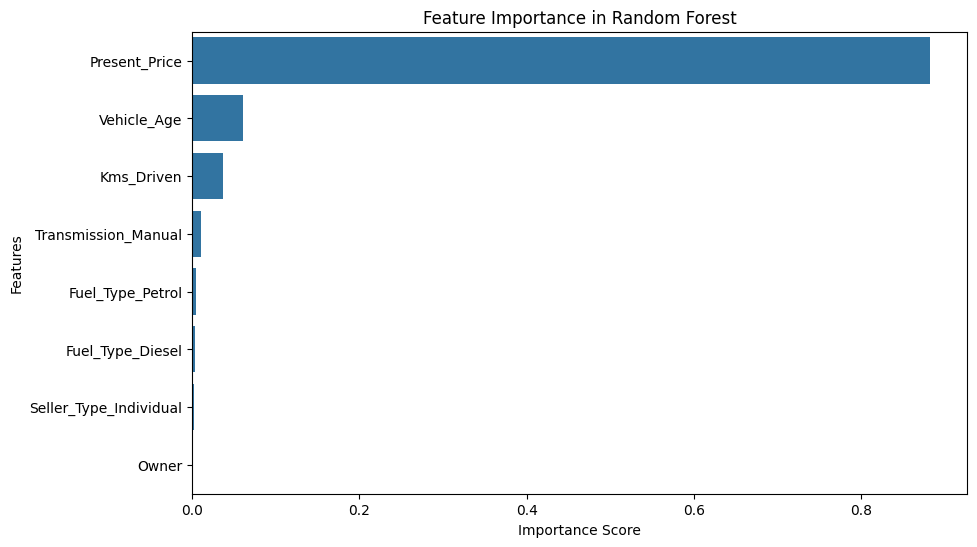

In [ ]:
# =========================================================
# FEATURE IMPORTANCE VISUALIZATION
# =========================================================

# Get feature importance values
importance = rf_model.feature_importances_

# Feature names
feature_names = X.columns

# Create dataframe
feature_df = pd.DataFrame({

    "Feature": feature_names,
    "Importance": importance

})

# Sort values
feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)

# Display dataframe
print(feature_df)


# =========================================================
# PLOT FEATURE IMPORTANCE
# =========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_df
)

plt.title("Feature Importance in Random Forest")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

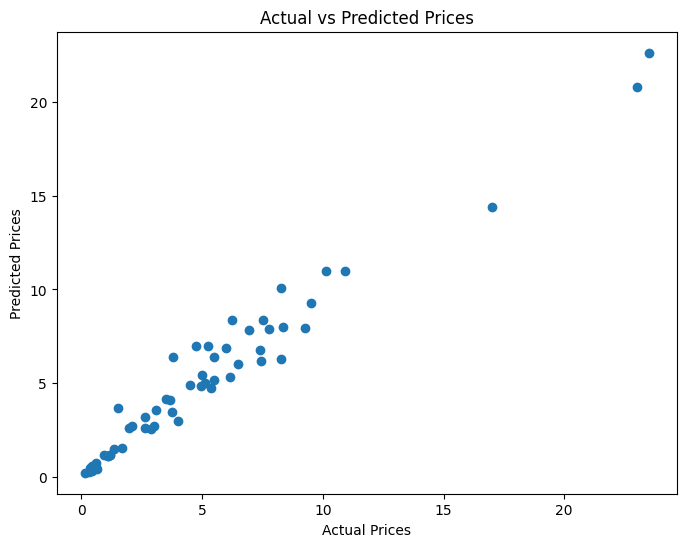

In [ ]:
# Actual vs Predicted Plot

plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.show()

In [ ]:
#Save Model
import pickle

pickle.dump(rf_model, open("car_price_model.pkl", "wb"))

In [ ]:
# Export cleaned dataset to CSV

df.to_csv("cleaned_car_data.csv", index=False)

print("Cleaned dataset exported successfully")

Cleaned dataset exported successfully
